In [154]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error

# 查看训练集数据，确定缺失值的处理方法

## 读取训练集，一共80个特征

In [155]:
train_df = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv", index_col = 0)
print((train_df.columns))

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

精心挑选其中的评估类特征(其实是猜的)，这18个特征提前处理.

In [156]:
key_features = ['OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 
                'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
                'BsmtFinType2', 'HeatingQC', 'KitchenQual',  'Functional', 
                'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'CentralAir']

## 确定重要特征, 作图

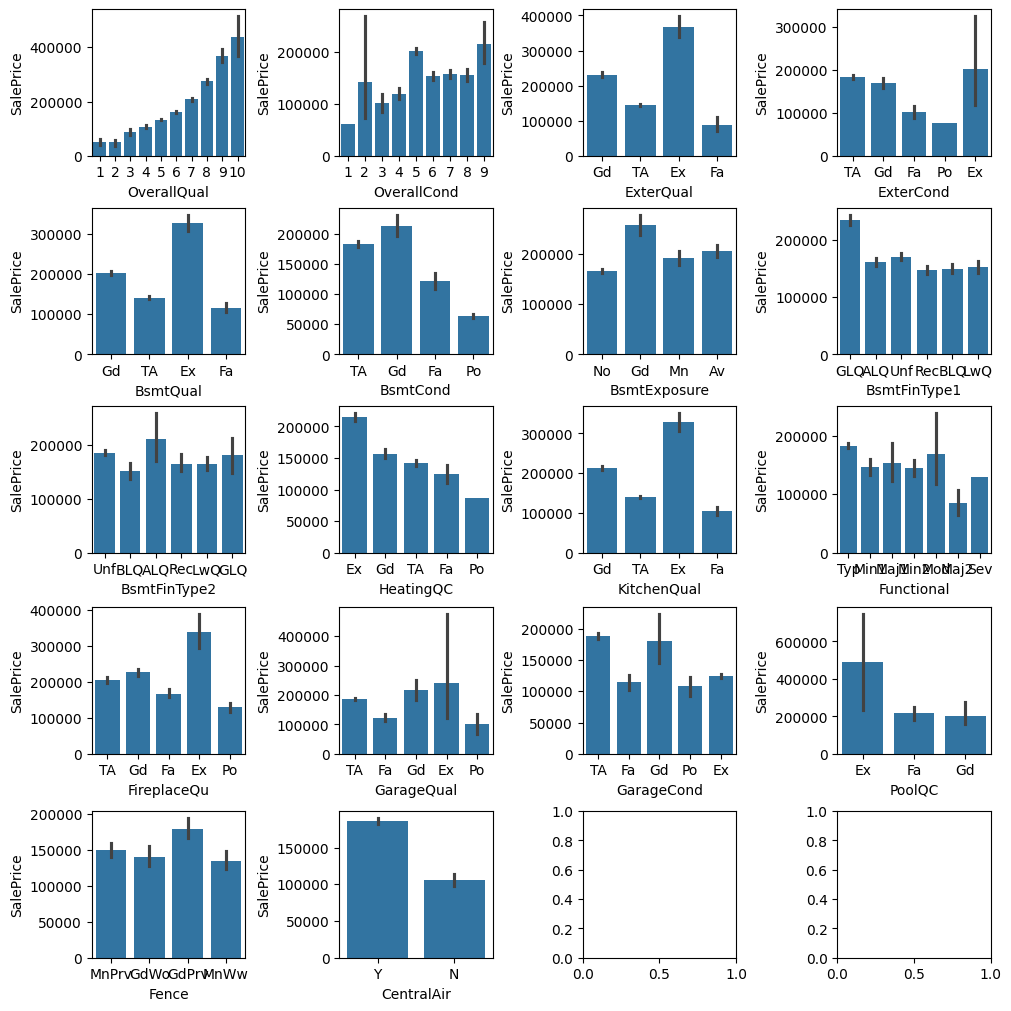

In [157]:
fig, ax =plt.subplots(5,4,constrained_layout=True, figsize=(10, 10))
ax = ax.flatten()
for i in range(18):
    sns.barplot(x = train_df[key_features[i]], y = train_df['SalePrice'], ax = ax[i])

In [158]:
# 定义一个列表，每个元素为 (列名, 映射字典)
mappings = [
    ('ExterQual', {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}),
    ('ExterCond', {'Ex': 5, 'Gd': 3, 'TA': 4, 'Fa': 2, 'Po': 1, 'NA': 0}),
    ('BsmtQual', {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}),
    ('BsmtCond', {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}),
    ('BsmtExposure', {'Gd': 5, 'Av': 4, 'Mn': 3, 'No': 2, 'NA': 1}),
    ('BsmtFinType1', {'GLQ': 6, 'ALQ': 4, 'BLQ': 2, 'Rec': 1, 'LwQ': 3, 'Unf': 5, 'NA': 0}),
    ('BsmtFinType2', {'GLQ': 4, 'ALQ': 6, 'BLQ': 1, 'Rec': 3, 'LwQ': 2, 'Unf': 5, 'NA': 0}),
    ('HeatingQC', {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}),
    ('KitchenQual', {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}),
    ('Functional', {'Typ': 8, 'Min1': 5, 'Min2': 4, 'Mod': 7, 'Maj1': 6, 'Maj2': 2, 'Sev': 3, 'Sal': 1, 'NA': 0}),
    ('FireplaceQu', {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}),
    ('GarageQual', {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}),
    ('GarageCond', {'Ex': 3, 'Gd': 4, 'TA': 5, 'Fa': 2, 'Po': 1, 'NA': 0}),
    ('PoolQC', {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}),
    ('Fence', {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'NA': 0}), 
    ('CentralAir', {'Y': 2, 'N': 1, 'NA': 0})
]

for col, mapping in mappings:
    train_df[col] = train_df[col].map(mapping)

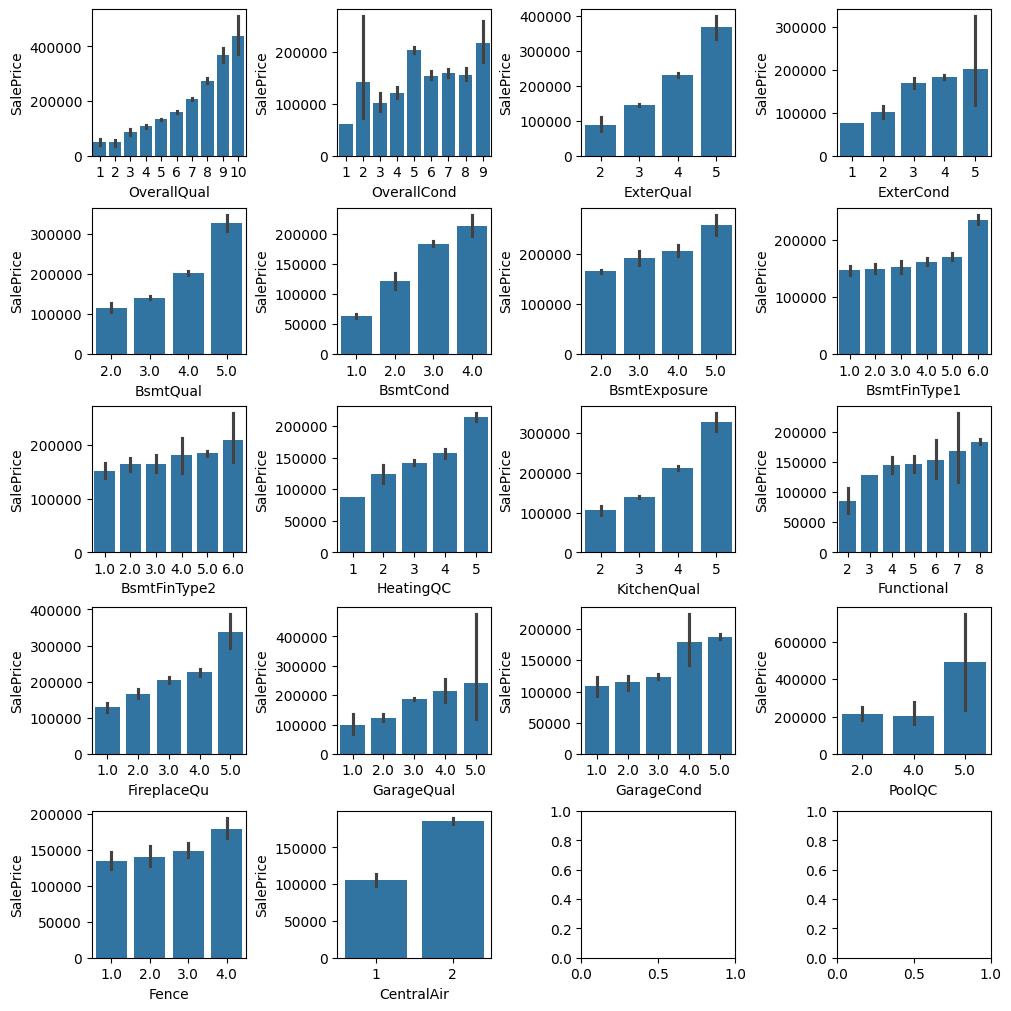

In [159]:
fig, ax =plt.subplots(5,4,constrained_layout=True, figsize=(10, 10))
ax = ax.flatten()
for i in range(18):
    sns.barplot(x = train_df[key_features[i]], y = train_df['SalePrice'], ax = ax[i])

## 查看剩余特征

In [160]:
all_features = train_df.columns.tolist()
# 排除 key_features 和 SalePrice
features = [col for col in all_features if col not in key_features and col != 'SalePrice']
features_object = [
    'MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour',
    'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1',
    'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
    'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation',
    'Heating', 'Electrical', 'GarageType', 'GarageFinish', 'PavedDrive',
    'MiscFeature', 'MoSold', 'SaleType', 'SaleCondition']
features_numeric = [
    'LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
    '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
    'FullBath', 'HalfBath', 'Bedroom', 'Kitchen', 'TotRmsAbvGrd',
    'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
    'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
    'MiscVal', 'YrSold']
len(features_object), len(features_numeric)

(29, 32)

## 处理缺失值

先合并train和test

In [161]:
test_df = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv", index_col = 0)


#### 对高基数类别特征（如 Neighborhood）使用训练集的平均房价（平滑处理）

In [162]:
# 假设 train_df 和 test_df 是原始数据（未编码）
# 对 Neighborhood 进行目标编码（使用训练集的均值）
neigh_means = train_df.groupby('Neighborhood')['SalePrice'].mean()
train_df['Neighborhood_target'] = train_df['Neighborhood'].map(neigh_means)
test_df['Neighborhood_target'] = test_df['Neighborhood'].map(neigh_means).fillna(train_df['SalePrice'].mean())

In [163]:
all_df = pd.concat((train_df, test_df),axis = 0)
key_features.append('SalePrice')
#all_df = all_df[key_features]        #删除不需要的特征
all_df.shape

(2919, 81)

评估类特征缺失值处理

In [164]:
for col, mapping in mappings:
    all_df[col] = all_df[col].map(mapping)

In [165]:
#**KitchenQual**：厨房质量 和 **Functional**：住宅功能性应填充为平均
all_df['KitchenQual'] = all_df['KitchenQual'].fillna(3)
all_df['Functional'] = all_df['Functional'].fillna(8)

for fea in key_features:
    all_df[fea] = all_df[fea].fillna(0)

其余特征缺失值处理

In [166]:
all_df.fillna({'MSZoning': all_df['MSZoning'].mode()[0]}, inplace = True)
all_df.fillna({'LotFrontage': all_df['LotFrontage'].median()}, inplace=True)
all_df.fillna({'Alley': 'NA'}, inplace=True)
all_df.fillna({'Utilities': all_df['Utilities'].mode()[0]}, inplace = True)
all_df.fillna({'Exterior1st': all_df['Exterior1st'].mode()[0]}, inplace = True)
all_df.fillna({'Exterior2nd': all_df['Exterior2nd'].mode()[0]}, inplace = True)
#处理'MasVnrType', 'MasVnrArea'
all_df.fillna({'MasVnrType': all_df['MasVnrType'].mode()[0]}, inplace=True)
# 将 MasVnrArea 为 0 或空的行对应的 MasVnrType 设为 None
mask = (all_df['MasVnrArea'] == 0) | (all_df['MasVnrArea'].isna())
all_df.loc[mask, 'MasVnrType'] = 'None'
mean_area = all_df.loc[(all_df['MasVnrType'] != 0), 'MasVnrArea'].mean()
all_df.fillna({'MasVnrArea': mean_area}, inplace=True)
mask = all_df['MasVnrType'] == 0
all_df.loc[mask, 'MasVnrArea'] = 0

all_df.fillna({'BsmtFinSF1': 0}, inplace=True)
all_df.fillna({'BsmtFinSF2': 0}, inplace=True)
all_df.fillna({'BsmtUnfSF': 0}, inplace=True)
all_df.fillna({'TotalBsmtSF': 0}, inplace=True)
all_df.fillna({'Electrical': all_df['Electrical'].mode()[0]}, inplace = True)
all_df.fillna({'BsmtFullBath': 0}, inplace=True)
all_df.fillna({'BsmtHalfBath': 0}, inplace=True)
all_df.fillna({'GarageType': 'NA'}, inplace=True)
all_df.fillna({'GarageYrBlt': 0}, inplace=True)
all_df.fillna({'GarageFinish': 0}, inplace=True)
all_df.fillna({'GarageCars': 0}, inplace=True)
all_df.fillna({'GarageArea': 0}, inplace=True)
all_df.fillna({'MiscFeature': all_df['MiscFeature'].mode()[0]}, inplace=True)
# 将 MasVnrArea 为 0 或空的行对应的 MasVnrType 设为 None
mask = (all_df['MiscVal'] == 0) | (all_df['MiscVal'].isna())
all_df.loc[mask, 'MiscFeature'] = 'NA'
all_df.fillna({'SaleType': 'Oth'}, inplace=True)

In [167]:
pd.isnull(all_df).sum().sum()

np.int64(0)

## 创建新特征

目标编码（Target Encoding）：对高基数类别特征（如 Neighborhood）使用训练集的平均房价（平滑处理）。

交互特征：例如 OverallQual * GrLivArea，TotalSF * OverallQual。

多项式特征：对重要数值特征（GrLivArea, LotArea, TotalSF）取平方或对数（但树模型对单调变换不敏感，可做但不一定有效）。

缺失值指示特征：对缺失率高的特征（LotFrontage, Alley 等）添加“是否有缺失”的二值特征。

建议每次只加一组特征，用 LightGBM 验证，避免过拟合。

In [168]:
all_df['f1'] = 2 * np.log1p(all_df['OverallQual']) + np.log1p(all_df['OverallCond']) + np.log1p(all_df['GrLivArea']) 
all_df['f2'] = all_df['OverallCond'] * (all_df['1stFlrSF'] + all_df['2ndFlrSF']) 


In [169]:
# #'ExterQual', 'BsmtQual','KitchenQual'形状一致, 相加作为新特征
# all_df['Qual'] = all_df['ExterQual'] + all_df['BsmtQual'] + all_df['KitchenQual']
# key_features.append('Qual')

In [170]:
# # 删除 GrLivArea 极大但 SalePrice 极低的样本（常见于训练集）----会导致过拟合
# train_df = train_df.drop(train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)].index)

数据重新分回数据集

In [171]:
fill_train_df = all_df.loc[train_df.index]
fill_test_df = all_df.loc[test_df.index]

## 独热化编码

In [172]:
# 假设 fill_train_df 和 fill_test_df 已经包含了所有原始列
# 分离目标变量
y_train = fill_train_df['SalePrice']
X_train_raw = fill_train_df.drop('SalePrice', axis=1)
X_test_raw = fill_test_df.drop('SalePrice', axis=1)

# 对分类特征进行 one-hot 编码
X_train = pd.get_dummies(X_train_raw, drop_first=True)  # drop_first 避免共线性
X_test = pd.get_dummies(X_test_raw, drop_first=True)

# 确保训练集和测试集列一致（测试集可能缺少某些类别）
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 带入模型

## 划分验证集

In [173]:
from sklearn.model_selection import train_test_split

X = X_train
y_log = np.log1p(y_train)

X_train, X_val, y_train, y_val = train_test_split(X, y_log, test_size=0.3, random_state=42)

## 岭回归

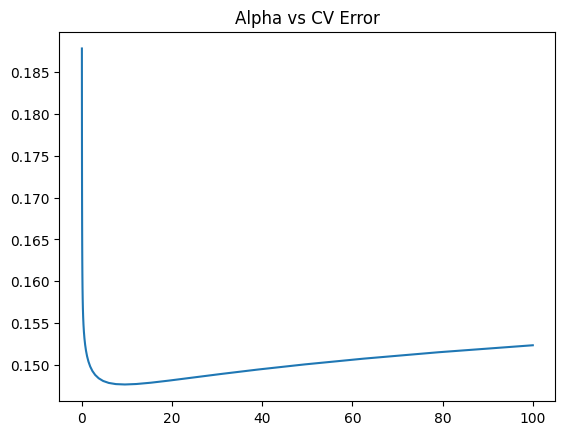

In [174]:
#岭回归Ridge Regression

from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

#通过交叉验证选择模型与参数
alphas = np.logspace(-3, 2, 50)
test_scores = []
for alpha in alphas:
    clf = Ridge(alpha)
    test_score = np.sqrt(-cross_val_score(clf, X_train, y_train, cv = 10, scoring = 'neg_mean_squared_error'))
    test_scores.append(np.mean(test_score))
plt.plot(alphas, test_scores)
plt.title("Alpha vs CV Error")
best_alpha = alphas[np.argmin(test_scores)]

In [175]:
print(np.min(test_scores), best_alpha)

0.14767315510073387 9.540954763499943


In [176]:
best_ridge = Ridge(alpha=best_alpha)
best_ridge.fit(X_train, y_train)
y_pred_val = best_ridge.predict(X_val)
rmsle_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
print(f'Validation RMSLE: {rmsle_val:.5f}')

Validation RMSLE: 0.13018


## 随机森林

In [177]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.model_selection import RandomizedSearchCV
# import numpy as np

# # 参数空间
# param_dist = {
#     'n_estimators': [100, 200, 300],
#     'max_features': [0.2, 0.4, 0.6, 0.8, 1.0],
#     'max_depth': [10, 20, 30, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# rf = RandomForestRegressor(random_state=42, n_jobs=-1)
# random_search = RandomizedSearchCV(
#     rf, param_distributions=param_dist,
#     n_iter=50, cv=5, scoring='neg_mean_squared_error',
#     random_state=42, n_jobs=-1, return_train_score=True
# )

# random_search.fit(X_train, y_train)   # y_log 是对数变换后的房价
# best_params = random_search.best_params_
# print("Best params:", best_params)
# # 在 random_search.fit(X, y_log) 之后

# # 最佳参数的负MSE
# neg_mse = random_search.best_score_
# # 转换为正MSE
# mse = -neg_mse
# # 计算RMSE
# rmse = np.sqrt(mse)

# print(f"Best cross-validated RMSE: {rmse:.4f}")

## LightGBM

In [178]:
import lightgbm as lgb
from sklearn.model_selection import ParameterSampler

# 参数空间
param_space = {
    'num_leaves': [15, 31, 63, 127],
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
    'feature_fraction': [0.6, 0.8, 1.0],
    'bagging_fraction': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [0, 0.1, 1.0],
    'min_child_samples': [5, 10, 20]
}

best_score = float('inf')
best_params = None

for params in ParameterSampler(param_space, n_iter=20, random_state=42):
    params['objective'] = 'regression'
    params['metric'] = 'rmse'
    params['boosting'] = 'gbdt'
    params['verbosity'] = -1
    
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
    
    model = lgb.train(
        params,
        train_data,
        valid_sets=[val_data],
        num_boost_round=500,
        callbacks=[lgb.early_stopping(50)],
    )
    score = model.best_score['valid_0']['rmse']
    if score < best_score:
        best_score = score
        best_params = params
        print(f'New best: {best_score:.5f} with {best_params}')

print(f'Best RMSLE: {best_score:.5f}')
print(f'Best params: {best_params}')

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[141]	valid_0's rmse: 0.124943
New best: 0.12494 with {'reg_lambda': 1.0, 'reg_alpha': 0.1, 'num_leaves': 127, 'min_child_samples': 20, 'learning_rate': 0.05, 'feature_fraction': 0.8, 'bagging_fraction': 0.6, 'objective': 'regression', 'metric': 'rmse', 'boosting': 'gbdt', 'verbosity': -1}
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[60]	valid_0's rmse: 0.125009
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[262]	valid_0's rmse: 0.128756
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[87]	valid_0's rmse: 0.130051
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's rmse: 0.131497
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is

In [191]:
y_pred_lasso = best_ridge.predict(X_val)
y_pred_gbm = model.predict(X_val)

pred_ensemble = 0.4 * y_pred_lasso + 0.6 * y_pred_gbm
rmsle_ensemble = np.sqrt(mean_squared_error(y_val, pred_ensemble))
print(f'Ensemble RMSLE: {rmsle_ensemble:.5f}')

Ensemble RMSLE: 0.12198 0.9500000000000001


# 确定最好的模型

岭回归

In [180]:
best = Ridge(alpha = best_alpha)
best.fit(X, y_log)
y_final = best.predict(X_test)
y_final_lasso = np.expm1(y_final)

lightgbm

In [181]:
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
best = lgb.train(params=best_params,                # 最优参数字典
    train_set=lgb.Dataset(X, y_log),   # X: 全部训练特征, y_log: 取对数后的目标
    num_boost_round=1000,
    valid_sets=[val_data],  # 如果有验证集的话，用于早停
    callbacks=[lgb.early_stopping(50)])   

y_final = best.predict(X_test)
y_final_gbm = np.expm1(y_final)

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's rmse: 0.0666814


In [182]:
y_final = 0.3 * y_final_lasso + y_final_gbm * 0.7

# 提交

In [183]:
#提交
submission_df = pd.DataFrame(data = {"Id": X_test.index, "SalePrice": y_final})
submission_df.to_csv('submission.csv', index = False)